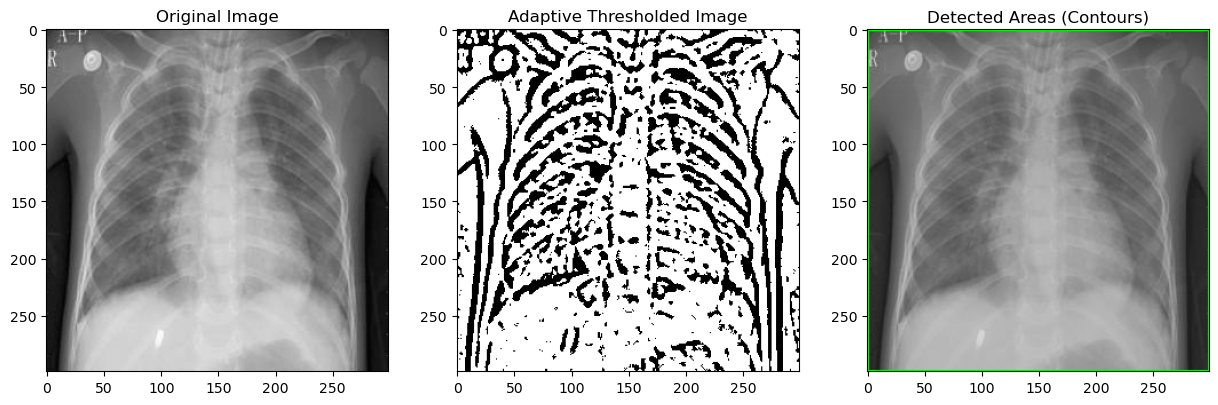

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_lung_cancer(image_path, threshold_value, min_area=500):
    # Read the image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Check if the image was loaded
    if image is None:
        print("Error: Could not load image.")
        return

    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(image, (5, 5), 0)

    # Use adaptive thresholding to detect more areas
    adaptive_thresholded = cv2.adaptiveThreshold(
        blurred, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2
    )

    # Optionally, apply morphological operations like dilation to make smaller areas more prominent
    dilated = cv2.dilate(adaptive_thresholded, None, iterations=3)

    # Find contours in the thresholded (dilated) image
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Filter contours based on minimum area size
    filtered_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]

    # Create a copy of the original image to draw contours on
    output_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    # Draw the contours on the output image
    for contour in filtered_contours:
        # Draw a bounding box around each contour
        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 2)  # Green rectangle

    # Display the original, thresholded, and final output images
    plt.figure(figsize=(15, 7))

    # Original Image
    plt.subplot(1, 3, 1)
    plt.title('Original Image')
    plt.imshow(image, cmap='gray')

    # Adaptive Thresholded Image
    plt.subplot(1, 3, 2)
    plt.title('Adaptive Thresholded Image')
    plt.imshow(adaptive_thresholded, cmap='gray')

    # Output Image with Contours
    plt.subplot(1, 3, 3)
    plt.title('Detected Areas (Contours)')
    plt.imshow(output_image)

    plt.show()

# Example usage
image_path = '1.jpg'  # Change to your image path
threshold_value = 100  # Adjust this value based on your image
detect_lung_cancer(image_path, threshold_value)
